In [126]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy.ndimage import label
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [127]:
import os
try:
    os.chdir("/home/maniacalm/bin/VQVAE_studies")
except FileNotFoundError:
    print("Either filepath is wrong or this is ran on another computer")

In [128]:
import numpy as np
import matplotlib.pyplot as plt

a=np.load("snb-Z-signal-0.npy",allow_pickle=True)
c=np.load("snb-Z-clnsig-0.npy",allow_pickle=True)
nwf=a.size
ntcks=len(a[0])-54
train_noise = []
train_signal = []
for j in range(nwf-50):
    ya=[]
    yc=[]
    j=0
    for i in range(0,ntcks):
        lab='tck_'+str(i)
        ya.append(a[j][lab])
        yc.append(c[j][lab])
    train_noise.append(ya)
    train_signal.append(yc)
test_noise = []
test_signal = []
for j in range(nwf-50,nwf-1):
    ya=[]
    yc=[]
    j=0
    for i in range(0,ntcks):
        lab='tck_'+str(i)
        ya.append(a[j][lab])
        yc.append(c[j][lab])
    test_noise.append(ya)
    test_signal.append(yc)
train_noise_c = np.reshape(np.array(train_noise), (-1, 1,512))
train_signal_c = np.reshape(np.array(train_signal), (-1, 1,512))
test_noise_c = np.reshape(np.array(test_noise), (-1, 1,512))
test_signal_c = np.reshape(np.array(test_signal), (-1, 1,512))
print(len(train_noise_c))
print(train_noise_c.shape)

196
(196, 1, 512)


In [129]:
class NoisyToClean1DDataset(Dataset):
    def __init__(self, noisy, clean, normalize=True):
        self.noisy = noisy.astype(np.float32)
        self.clean = clean.astype(np.float32)
        self.normalize = normalize

    def __len__(self):
        return len(self.noisy)

    def __getitem__(self, idx):
        x = self.noisy[idx]   # (1, 512)
        y = self.clean[idx]   # (1, 512)

        if self.normalize:
            mu = x.mean()
            sd = x.std() + 1e-6
            x = (x - mu) / sd
            y = (y - mu) / sd

        return {
            "x": torch.from_numpy(x).float(),
            "y": torch.from_numpy(y).float(),
        }

In [130]:
train_ds_full = NoisyToClean1DDataset(
    noisy=train_noise_c,
    clean=train_signal_c,
    normalize=True,
)

test_ds = NoisyToClean1DDataset(
    noisy=test_noise_c,
    clean=test_signal_c,
    normalize=True,
)

n_val = int(0.1 * len(train_ds_full))
n_train = len(train_ds_full) - n_val

train_ds, val_ds = random_split(
    train_ds_full,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42),
)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

batch = next(iter(train_loader))
batch["x"].shape, batch["y"].shape

(torch.Size([64, 1, 512]), torch.Size([64, 1, 512]))

In [131]:
import random as rng

def get_gaussian(mu,sigma):
    def gaussian(x):
        a = -1/2 * (x-mu)**2/sigma**2
        return np.exp(a)/(sigma*np.sqrt(2*np.pi))
    return np.vectorize(gaussian)
def get_ReLU(freq):
    def ReLU(x):
        return abs((x) * (x > 1-freq))
    return ReLU

class simulacra_dataset(Dataset):
    """simulacra of simulated data of neutrinos dataset."""

    def __init__(self, min_val, max_val, target_snr, length, seed, pusle_length):
        """
        Arguments:
            csv_file (string): Path to the csv file with annotations.
            root_dir (string): Directory with all the images.
            transform (callable, optional): Optional transform to be applied
                on a sample.
        """
        self.min_val = min_val
        self.max_val = max_val
        self.target_snr = target_snr
        self.length = length
        self.seed = seed
        self.pusle_length = pusle_length

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        np.random.seed(idx+self.seed)
        relu1 = get_ReLU(0.2)
        relu2 = get_ReLU(0.3)
        mu1 = random.randint(self.min_val,self.max_val)
        sigma1 = random.randint(10,30)
        mu2 = random.randint(self.min_val,self.max_val)
        sigma2 = random.randint(10,30)
        weight1 = relu1(rng.random())
        weight2 = relu2(rng.random())
        pulse = [get_gaussian(mu1,sigma1),get_gaussian(mu1+sigma1,sigma1),get_gaussian(mu2,sigma2)]

        mu, sigma = 0, 0.1 # mean and standard deviation
        s = np.random.normal(mu, sigma, self.pusle_length)
        a = np.linspace(0,self.pusle_length,self.pusle_length)
        wave = pulse[0](a) - pulse[1](a)*weight1 + pulse[2](a)*weight2
        snr = max(wave)/max(s)
        weight = target_snr/snr
        res = wave*weight + s
        return {
            "x": torch.from_numpy(res).float().unsqueeze(0),
            "y": torch.from_numpy(wave*weight).float().unsqueeze(0),
        }

min_val, max_val, target_snr, length, seed, pusle_length = 20,500,100,100,0,512
train_ds = simulacra_dataset(min_val, max_val, target_snr, length, seed, pusle_length)
length, seed = 100,1000
val_ds = simulacra_dataset(min_val, max_val, target_snr, length, seed, pusle_length)
length, seed = 100,2000
test_ds = simulacra_dataset(min_val, max_val, target_snr, length, seed, pusle_length)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

batch = next(iter(train_loader))
batch["x"].shape, batch["y"].shape

(torch.Size([64, 1, 512]), torch.Size([64, 1, 512]))

In [ ]:
class ResBlock1D(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(c, c, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv1d(c, c, 3, padding=1),
        )

    def forward(self, x):
        return F.relu(x + self.net(x))

class FFTLayer(nn.Module):
    def forward(self, x):
        return torch.fft.rfft(x, dim=-1)

class iFFTLayer(nn.Module):
    def forward(self, x):
        return torch.fft.irfft(x, dim=-1)

class Encoder1D(nn.Module):
    def __init__(self, in_ch=1, hid=64, z_ch=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(512, 128),
            FFTLayer(),
        )

    def forward(self, x):
        return self.net(x)


class Decoder1D(nn.Module):
    def __init__(self, out_ch=1, hid=64, z_ch=64):
        super().__init__()
        self.net = nn.Sequential(
            iFFTLayer(),
            nn.Linear(128, 512)
        )

    def forward(self, z):
        return self.net(z)


class VectorQuantizer1D(nn.Module):
    def __init__(self, n_codes=512, code_dim=64, beta=0.25):
        super().__init__()
        self.beta = beta
        self.codebook = nn.Embedding(n_codes, code_dim)
        self.codebook.weight.data.uniform_(-1 / n_codes, 1 / n_codes)

    def forward(self, z_e):
        # z_e: (B, C, L)
        B, C, L = z_e.shape

        z = z_e.permute(0, 2, 1).contiguous().view(-1, C)

        d = (
            z.pow(2).sum(1, keepdim=True)
            + self.codebook.weight.pow(2).sum(1)
            - 2 * z @ self.codebook.weight.t()
        )

        idx = torch.argmin(d, dim=1)

        z_q = self.codebook(idx)
        z_q = z_q.view(B, L, C).permute(0, 2, 1).contiguous()

        codebook_loss = F.mse_loss(z_q, z_e.detach())
        commit_loss = F.mse_loss(z_e, z_q.detach())
        vq_loss = codebook_loss + self.beta * commit_loss

        z_q = z_e + (z_q - z_e).detach()

        return z_q, vq_loss, idx.view(B, L)


class VQVAE1DDenoiser(nn.Module):
    def __init__(self, in_ch=1, hid=64, z_ch=64, n_codes=512):
        super().__init__()
        self.enc = Encoder1D(in_ch, hid, z_ch)
        self.vq = VectorQuantizer1D(n_codes, z_ch)
        self.dec = Decoder1D(1, hid, z_ch)

    def forward(self, x):
        z_e = self.enc(x)
        z_q, vq_loss, codes = self.vq(z_e)
        clean_hat = self.dec(z_q)
        return clean_hat, vq_loss, codes
        return clean_hat, vq_loss, codes

In [193]:
model = VQVAE1DDenoiser(
    in_ch=1,
    hid=64,
    z_ch=64,
    n_codes=512,
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=1e-4,
)

model

VQVAE1DDenoiser(
  (enc): Encoder1D(
    (net): Sequential(
      (0): Linear(in_features=512, out_features=128, bias=True)
      (1): FFTLayer()
      (2): Conv1d(128, 64, kernel_size=(1,), stride=(1,))
    )
  )
  (vq): VectorQuantizer1D(
    (codebook): Embedding(512, 64)
  )
  (dec): Decoder1D(
    (net): Sequential(
      (0): iFFTLayer()
      (1): Linear(in_features=128, out_features=512, bias=True)
    )
  )
)

In [194]:
batch = next(iter(train_loader))

x = batch["x"].to(device)
y = batch["y"].to(device)

with torch.no_grad():
    y_hat, vq_loss, codes = model(x)

print("x:", x.shape)
print("y:", y.shape)
print("y_hat:", y_hat.shape)
print("codes:", codes.shape)
print("vq_loss:", vq_loss.item())

RuntimeError: Given groups=1, weight of size [64, 128, 1], expected input[64, 1, 65] to have 128 channels, but got 1 channels instead

In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-2,
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=10,
    min_lr=1e-6,
)

In [ ]:
def run_epoch(loader, train=True, lambda_vq=0.25, max_grad_norm=1.0):
    model.train() if train else model.eval()

    total_loss = 0.0
    total_recon = 0.0
    total_vq = 0.0
    skipped = 0

    for batch in loader:
        x = batch["x"].to(device)
        y = batch["y"].to(device)

        with torch.set_grad_enabled(train):
            y_hat, vq_loss, codes = model(x)

            recon_loss = F.smooth_l1_loss(y_hat, y)
            loss = recon_loss + lambda_vq * vq_loss

            if not torch.isfinite(loss):
                skipped += 1
                continue

            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=max_grad_norm,
                )

                optimizer.step()

        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_vq += vq_loss.item()

    n = max(1, len(loader) - skipped)

    return {
        "loss": total_loss / n,
        "recon": total_recon / n,
        "vq": total_vq / n,
        "skipped": skipped,
    }

In [ ]:
num_epochs = 100

history = {
    "train_loss": [],
    "val_loss": [],
    "train_recon": [],
    "val_recon": [],
    "train_vq": [],
    "val_vq": [],
    "lr": [],
}

best_val = float("inf")
best_state = None
patience = 50
bad_epochs = 0

for epoch in range(1, num_epochs + 1):

    # Warm up VQ loss so it does not dominate early training
    lambda_vq = min(0.25, 0.25 * epoch / 10)

    train_stats = run_epoch(
        train_loader,
        train=True,
        lambda_vq=lambda_vq,
        max_grad_norm=1.0,
    )

    val_stats = run_epoch(
        val_loader,
        train=False,
        lambda_vq=lambda_vq,
        max_grad_norm=1.0,
    )

    scheduler.step(val_stats["loss"])

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_stats["loss"])
    history["val_loss"].append(val_stats["loss"])
    history["train_recon"].append(train_stats["recon"])
    history["val_recon"].append(val_stats["recon"])
    history["train_vq"].append(train_stats["vq"])
    history["val_vq"].append(val_stats["vq"])
    history["lr"].append(current_lr)

    if val_stats["loss"] < best_val:
        best_val = val_stats["loss"]
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }
        bad_epochs = 0
    else:
        bad_epochs += 1

    print(
        f"Epoch {epoch:03d} | "
        f"lr {current_lr:.2e} | "
        f"lambda_vq {lambda_vq:.3f} | "
        f"train {train_stats['loss']:.6f} | "
        f"val {val_stats['loss']:.6f} | "
        f"recon {val_stats['recon']:.6f} | "
        f"vq {val_stats['vq']:.6f} | "
        f"skipped {train_stats['skipped']}"
    )

    if bad_epochs >= patience:
        print("Early stopping.")
        break

model.load_state_dict(best_state)
model.to(device)

Epoch 001 | lr 1.00e-02 | lambda_vq 0.025 | train 3.996900 | val 6.983899 | recon 3.569446 | vq 136.578133 | skipped 0
Epoch 002 | lr 1.00e-02 | lambda_vq 0.050 | train 41.535311 | val 424.464005 | recon 3.681196 | vq 8415.656006 | skipped 0
Epoch 003 | lr 1.00e-02 | lambda_vq 0.075 | train 820.712524 | val 638.478546 | recon 3.403022 | vq 8467.673340 | skipped 0
Epoch 004 | lr 1.00e-02 | lambda_vq 0.100 | train 618.686935 | val 104.056767 | recon 3.354886 | vq 1007.018799 | skipped 0
Epoch 005 | lr 1.00e-02 | lambda_vq 0.125 | train 84.245623 | val 16.978386 | recon 3.242977 | vq 109.883274 | skipped 0
Epoch 006 | lr 1.00e-02 | lambda_vq 0.150 | train 15.860342 | val 5.669557 | recon 3.361721 | vq 15.385570 | skipped 0
Epoch 007 | lr 1.00e-02 | lambda_vq 0.175 | train 5.280295 | val 3.880269 | recon 3.166834 | vq 4.076775 | skipped 0
Epoch 008 | lr 1.00e-02 | lambda_vq 0.200 | train 4.612016 | val 6.050727 | recon 3.338641 | vq 13.560431 | skipped 0
Epoch 009 | lr 1.00e-02 | lambda_vq

VQVAE1DDenoiser(
  (enc): Encoder1D(
    (net): Sequential(
      (0): Conv1d(1, 64, kernel_size=(4,), stride=(2,), padding=(1,))
      (1): ReLU(inplace=True)
      (2): Conv1d(64, 64, kernel_size=(4,), stride=(2,), padding=(1,))
      (3): ReLU(inplace=True)
      (4): ResBlock1D(
        (net): Sequential(
          (0): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
          (1): ReLU(inplace=True)
          (2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
        )
      )
      (5): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
    )
  )
  (vq): VectorQuantizer1D(
    (codebook): Embedding(512, 64)
  )
  (dec): Decoder1D(
    (net): Sequential(
      (0): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
      (1): ResBlock1D(
        (net): Sequential(
          (0): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
          (1): ReLU(inplace=True)
          (2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
        )
      )
  

In [ ]:
test_stats = run_epoch(test_loader, train=False, lambda_vq=0.25)
test_stats

{'loss': 4.779256105422974,
 'recon': 3.57809317111969,
 'vq': 4.804651260375977,
 'skipped': 0}

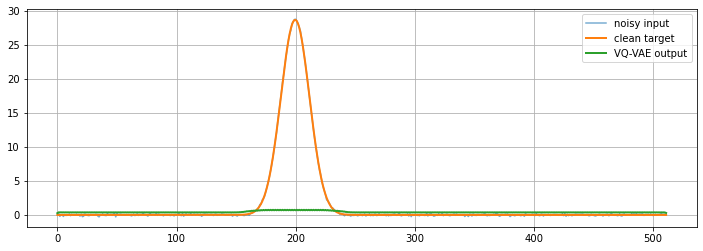

In [ ]:
model.eval()

batch = next(iter(test_loader))

x = batch["x"].to(device)
y = batch["y"].to(device)

with torch.no_grad():
    y_hat, vq_loss, codes = model(x)

idx = 0

noisy = x[idx, 0].cpu().numpy()
clean = y[idx, 0].cpu().numpy()
pred = y_hat[idx, 0].cpu().numpy()

plt.figure(figsize=(12, 4))
plt.plot(noisy, label="noisy input", alpha=0.6)
plt.plot(clean, label="clean target", linewidth=2)
plt.plot(pred, label="VQ-VAE output", linewidth=2)
plt.legend()
plt.grid(True)
plt.show()